# Week 2 — Data Cleaning & Exploratory Data Analysis (EDA)
**Project:** Proactive Employee Attrition Predictor (Project #6)
**Intern:** Apekshya Basnyat
**Program:** Techaxis Remote Data Science Internship 2026




## Step 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

print('All libraries imported successfully!')

All libraries imported successfully!


## Step 2 — Load Dataset

In [2]:
df = pd.read_csv('hr_attrition.csv')

print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Shape: 1470 rows, 35 columns


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


---
# PART 1 — DATA CLEANING
---

## Step 3 — Data Profiling

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0


In [5]:
df.describe(include='object').T

,count,unique,top,freq
Attrition,1470,2,No,1233
BusinessTravel,1470,3,Travel_Rarely,1043
Department,1470,3,Research & Development,961
EducationField,1470,6,Life Sciences,606
Gender,1470,2,Male,882
JobRole,1470,9,Sales Executive,326
MaritalStatus,1470,3,Married,673
Over18,1470,1,Y,1470
OverTime,1470,2,No,1054


## Step 4 — Check Missing Values

No missing values found! This dataset is already clean.


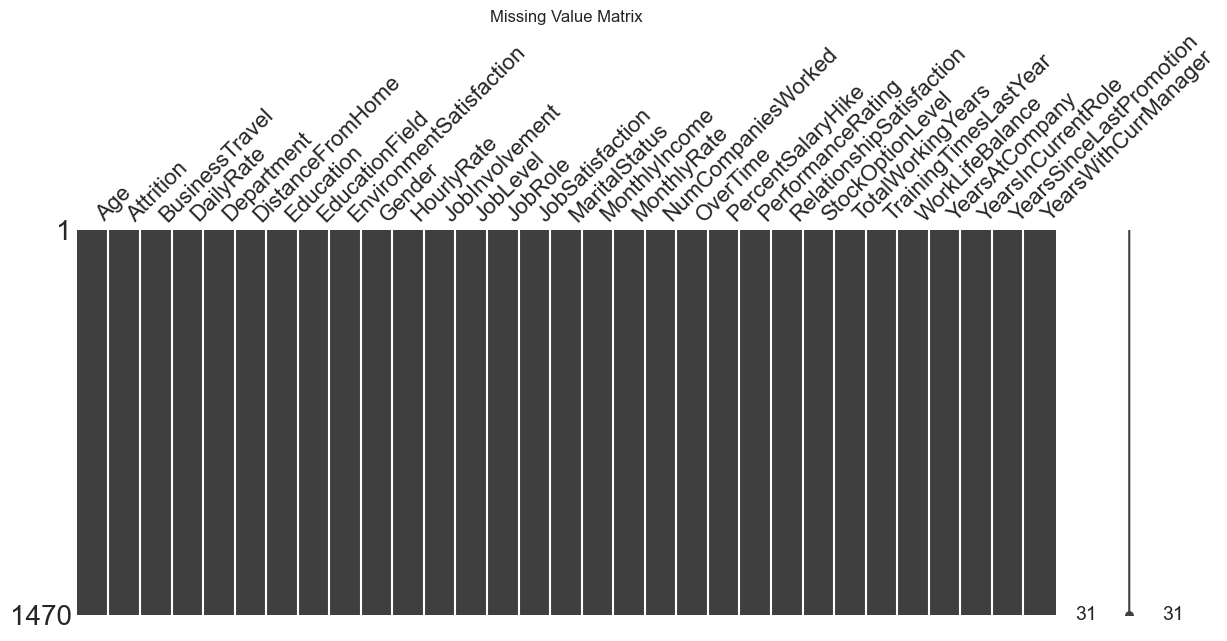

In [10]:
missing_df = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df) * 100).round(2)
})
missing_df = missing_df[missing_df['Missing Count'] > 0]

if missing_df.empty:
    print('No missing values found! This dataset is already clean.')
else:
    print(missing_df)

# Visualize regardless, as a profiling sanity check
msno.matrix(df, figsize=(14, 5))
plt.title('Missing Value Matrix')
plt.tight_layout()
plt.savefig('missing_value_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 5 — Drop Useless Columns


In [12]:
cols_to_drop = []
for col in df.columns:
    if df[col].nunique() == 1:
        print(f"Dropping (constant): {col} — only value: {df[col].unique()}")
        cols_to_drop.append(col)

# Also drop EmployeeNumber — a unique ID, not a feature
if 'EmployeeNumber' in df.columns:
    print(f"Dropping (identifier): EmployeeNumber — {df['EmployeeNumber'].nunique()} unique values")
    cols_to_drop.append('EmployeeNumber')

df.drop(columns=cols_to_drop, inplace=True)
print(f"\nShape after dropping useless columns: {df.shape}")


Shape after dropping useless columns: (1470, 31)


## Step 6 — Encode Target Variable

In [13]:
# Keep a readable label column, and create the binary flag used for analysis/modelling
df['Attrition_Label'] = df['Attrition']
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

print("Target encoded: Yes -> 1, No -> 0")
df[['Attrition_Label', 'Attrition']].head()

Target encoded: Yes -> 1, No -> 0


,Attrition_Label,Attrition
0,Yes,1
1,No,0
2,Yes,1
3,No,0
4,No,0


## Step 7 — Target Class Balance (Critical Finding)

Counts:
 Attrition_Label
No     1233
Yes     237
Name: count, dtype: int64

Percentages:
 Attrition_Label
No     83.88
Yes    16.12
Name: proportion, dtype: float64


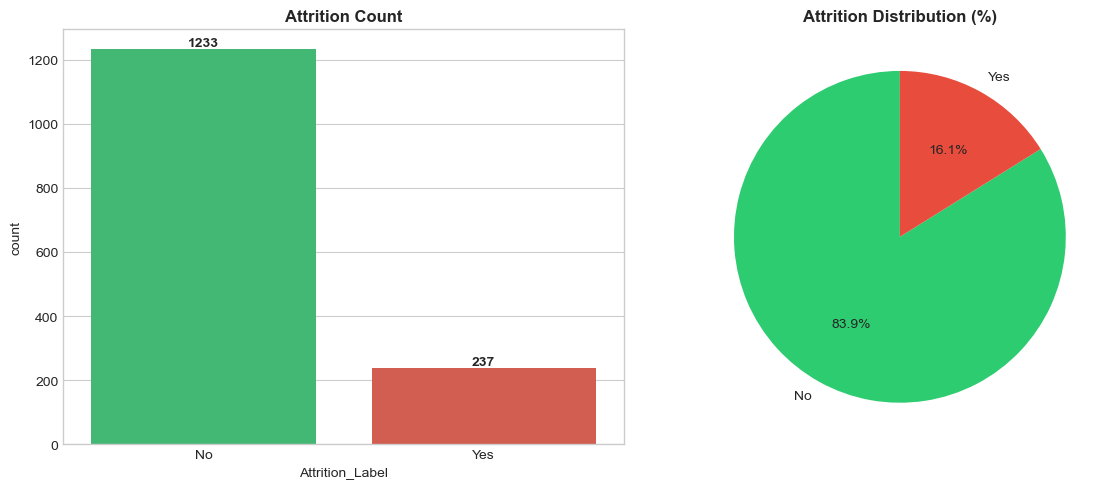

In [15]:
counts = df['Attrition_Label'].value_counts()
pct = df['Attrition_Label'].value_counts(normalize=True) * 100
print("Counts:\n", counts)
print("\nPercentages:\n", pct.round(2))

order = counts.index.tolist()
colors_map = {'No': '#2ecc71', 'Yes': '#e74c3c'}
colors = [colors_map.get(label, '#999999') for label in order]

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(data=df, x='Attrition_Label',
              order=order, palette=colors, ax=ax[0])
ax[0].set_title('Attrition Count', fontweight='bold')
for i, v in enumerate(counts.reindex(order)):
    ax[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

ax[1].pie(pct.reindex(order), labels=order, autopct='%1.1f%%',
          colors=colors, startangle=90)
ax[1].set_title('Attrition Distribution (%)', fontweight='bold')

plt.tight_layout()
plt.savefig('attrition_class_balance.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 8 — Detect Outliers using IQR Method

In [17]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_cols = [c for c in num_cols if c != 'Attrition']

outlier_report = []
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    if outliers > 0:
        outlier_report.append({'Column': col, 'Outlier Count': outliers,
                                'Outlier %': round(outliers/len(df)*100, 2),
                                'Lower Bound': round(lower, 2), 'Upper Bound': round(upper, 2)})

outlier_df = pd.DataFrame(outlier_report).sort_values('Outlier Count', ascending=False)
print("Columns with outliers (IQR method):")
print(outlier_df.to_string(index=False))

Columns with outliers (IQR method):
                 Column  Outlier Count  Outlier %  Lower Bound  Upper Bound
  TrainingTimesLastYear            238      16.19          0.5          4.5
      PerformanceRating            226      15.37          3.0          3.0
          MonthlyIncome            114       7.76      -5291.0      16581.0
YearsSinceLastPromotion            107       7.28         -4.5          7.5
         YearsAtCompany            104       7.07         -6.0         18.0
       StockOptionLevel             85       5.78         -1.5          2.5
      TotalWorkingYears             63       4.29         -7.5         28.5
     NumCompaniesWorked             52       3.54         -3.5          8.5
     YearsInCurrentRole             21       1.43         -5.5         14.5
   YearsWithCurrManager             14       0.95         -5.5         14.5


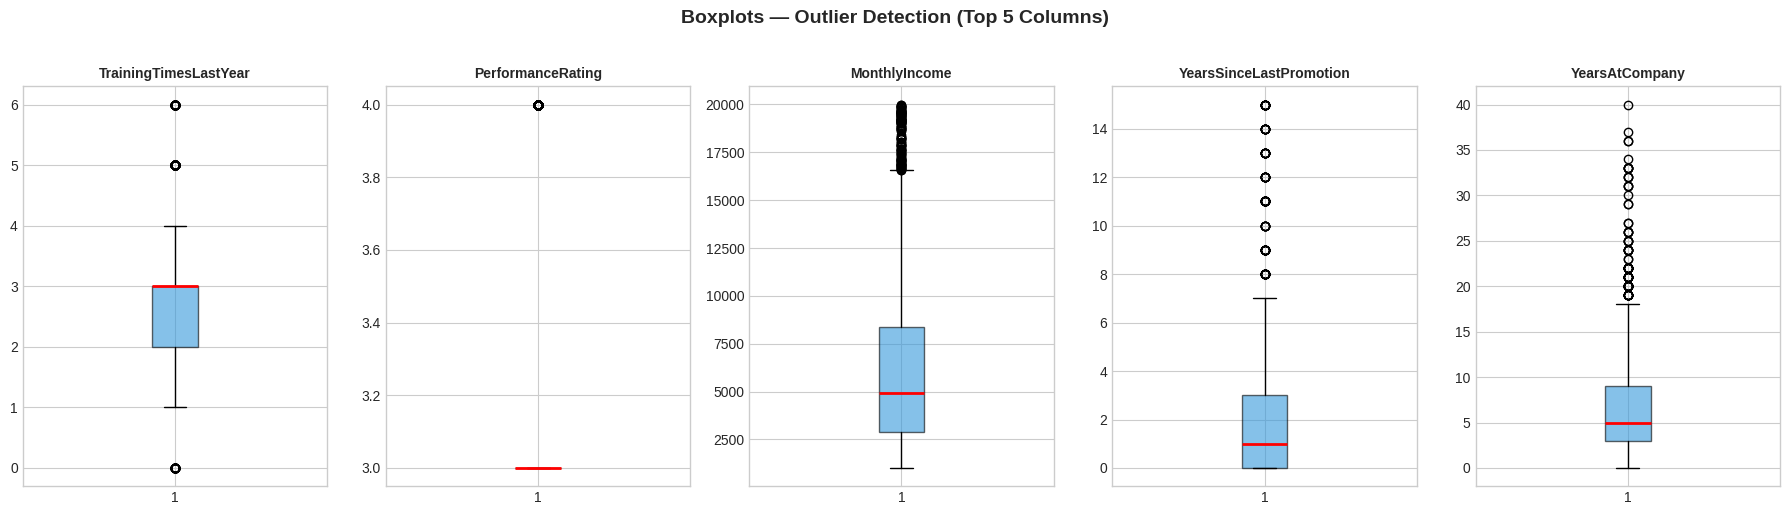

In [11]:
# Visualize the columns with the most outliers
key_cols = outlier_df['Column'].head(5).tolist()

fig, axes = plt.subplots(1, len(key_cols), figsize=(18, 5))
for i, col in enumerate(key_cols):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='#3498db', alpha=0.6),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('')

plt.suptitle('Boxplots — Outlier Detection (Top 5 Columns)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outlier_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

---
# PART 2 — EXPLORATORY DATA ANALYSIS
---

## Step 9 — Univariate Analysis: Numerical Columns

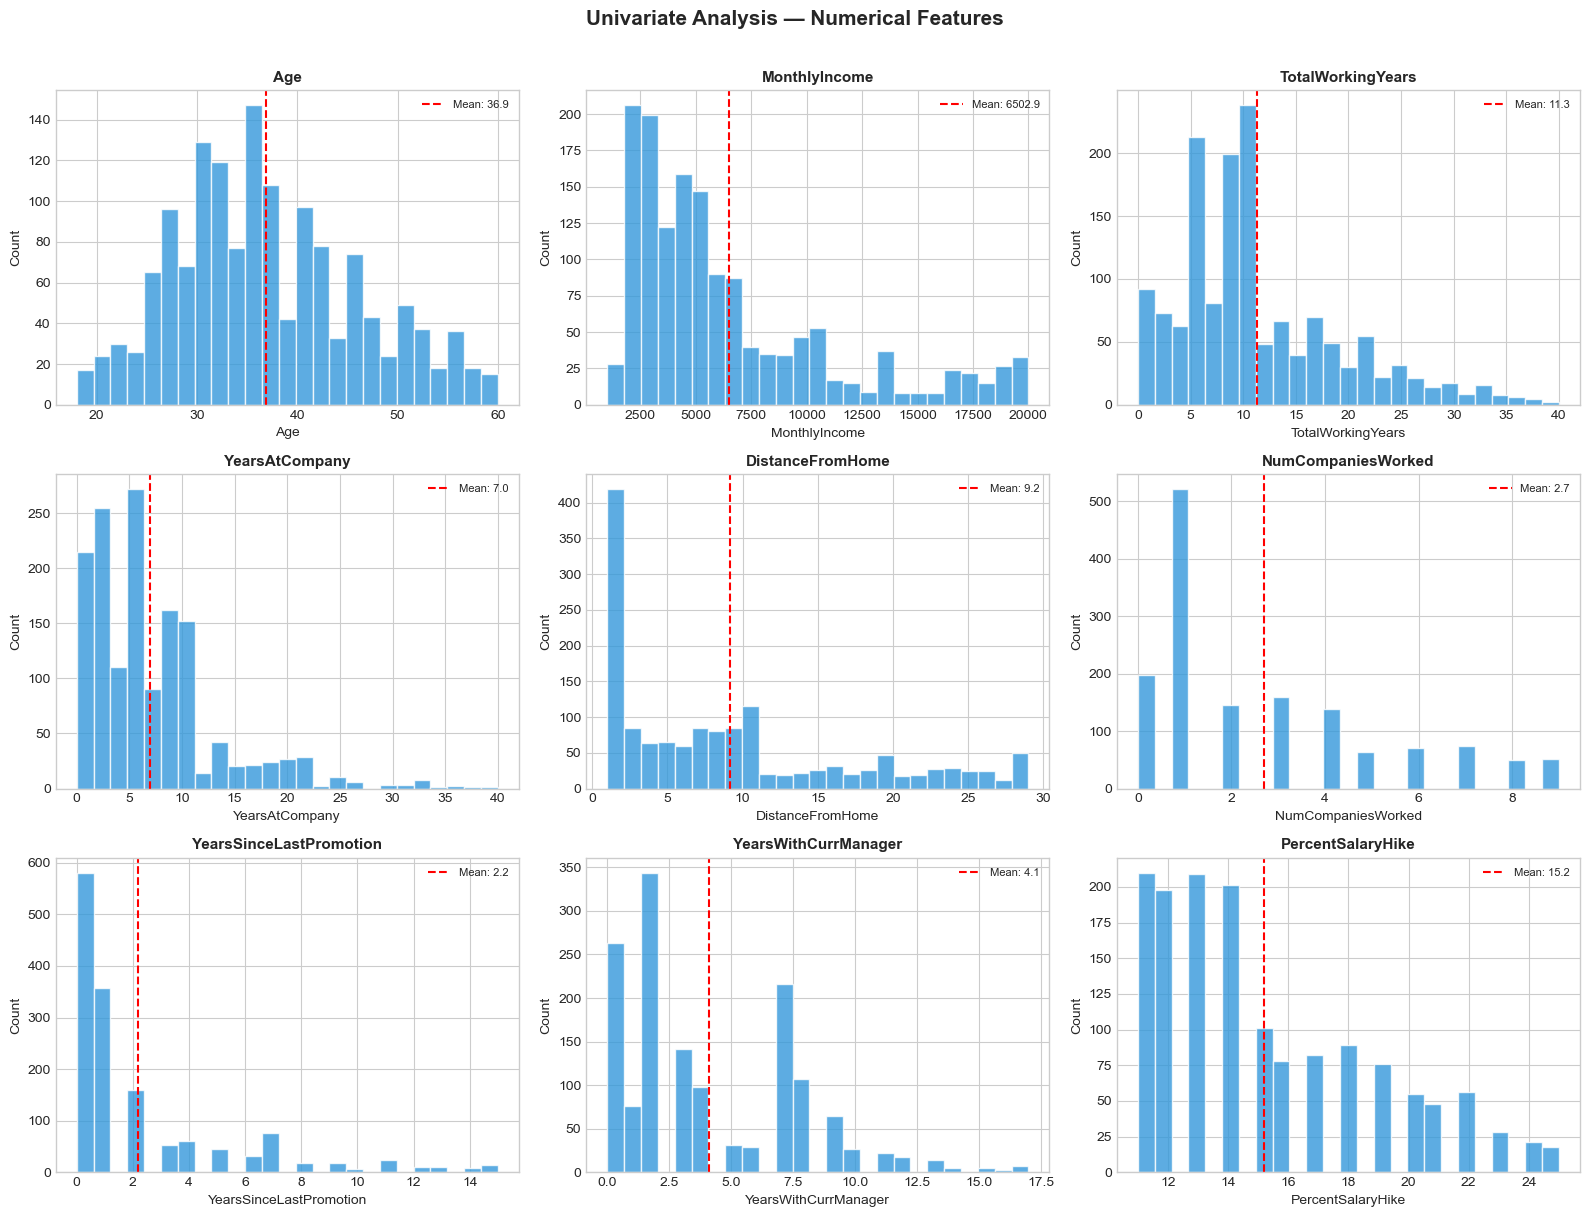

In [18]:
num_cols_plot = ['Age', 'MonthlyIncome', 'TotalWorkingYears', 'YearsAtCompany',
                 'DistanceFromHome', 'NumCompaniesWorked', 'YearsSinceLastPromotion',
                 'YearsWithCurrManager', 'PercentSalaryHike']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols_plot):
    axes[i].hist(df[col], bins=25, color='#3498db', alpha=0.8, edgecolor='white')
    axes[i].set_title(f'{col}', fontweight='bold', fontsize=11)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', linewidth=1.5,
                     label=f'Mean: {df[col].mean():.1f}')
    axes[i].legend(fontsize=8)

plt.suptitle('Univariate Analysis — Numerical Features', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('univariate_numerical.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 10 — Univariate Analysis: Categorical Columns

Categorical columns: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


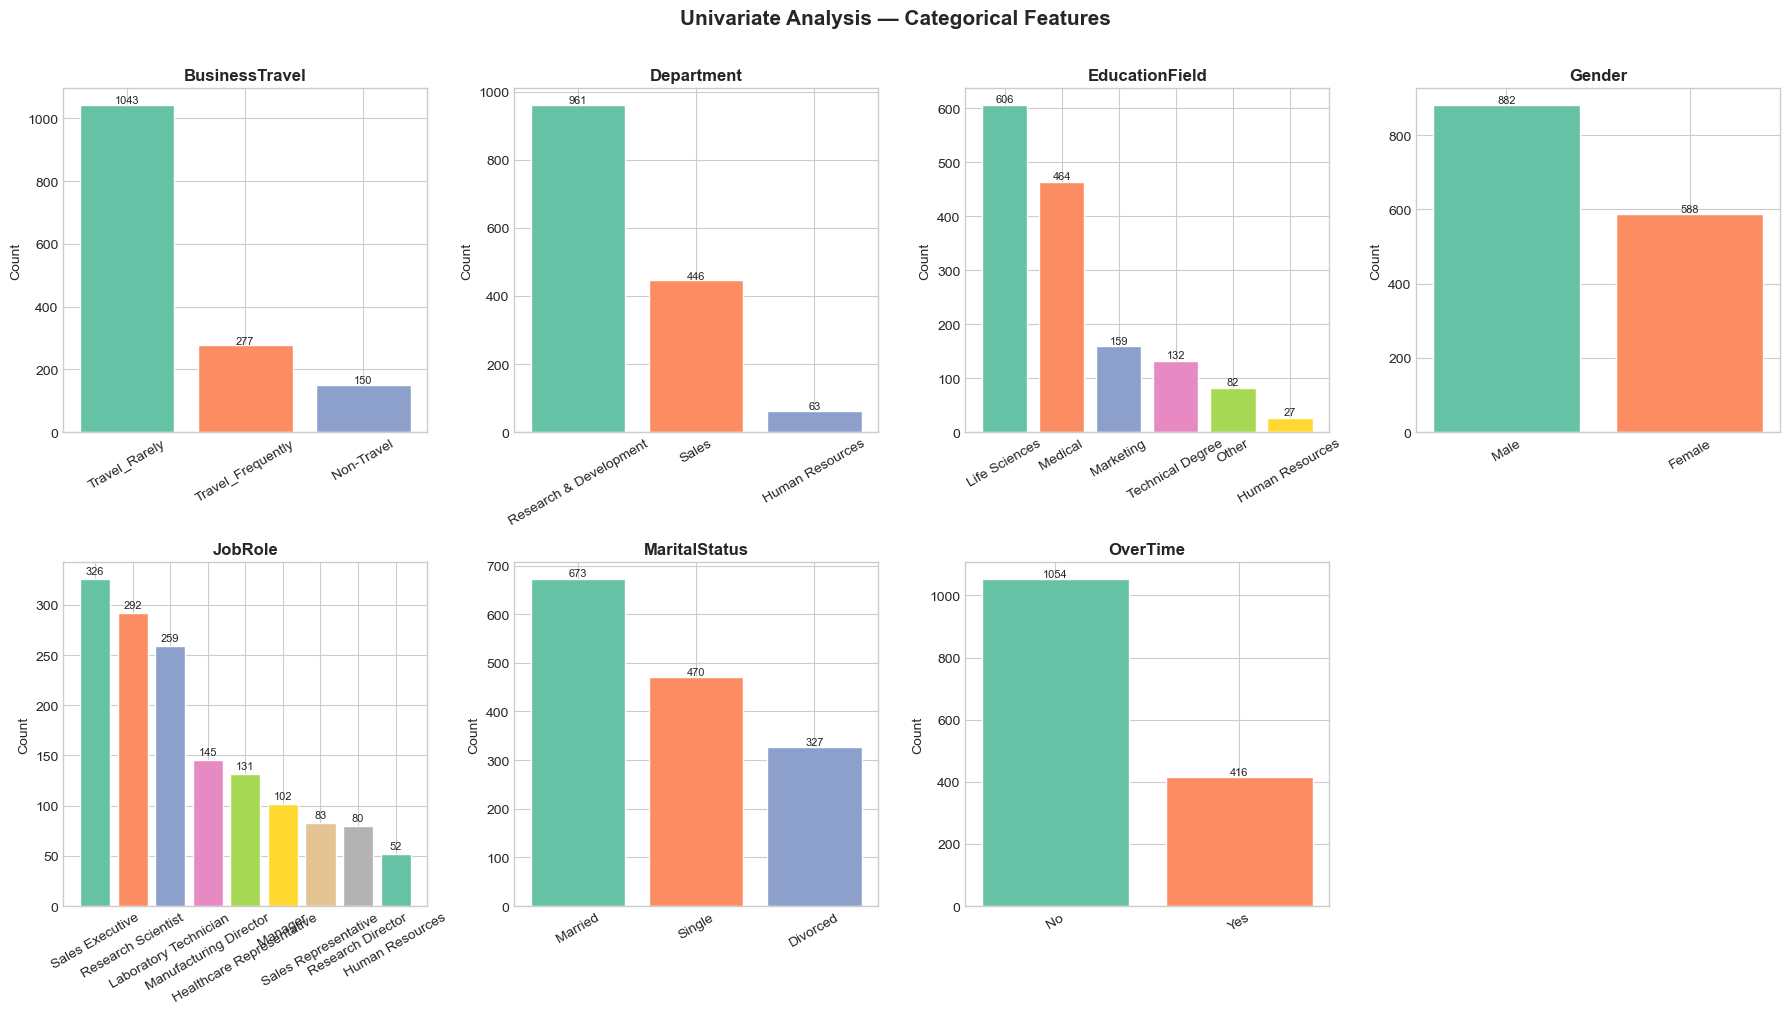

In [20]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
cat_cols = [c for c in cat_cols if c != 'Attrition_Label']
print(f"Categorical columns: {cat_cols}")

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols[:8]):
    vc = df[col].value_counts()
    axes[i].bar(vc.index, vc.values, color=sns.color_palette('Set2', len(vc)), edgecolor='white')
    axes[i].set_title(col, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].set_ylabel('Count')
    for bar in axes[i].patches:
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                     str(int(bar.get_height())), ha='center', fontsize=8)

for j in range(len(cat_cols[:8]), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Univariate Analysis — Categorical Features', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('univariate_categorical.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 11 — Bivariate Analysis: Categorical vs Attrition

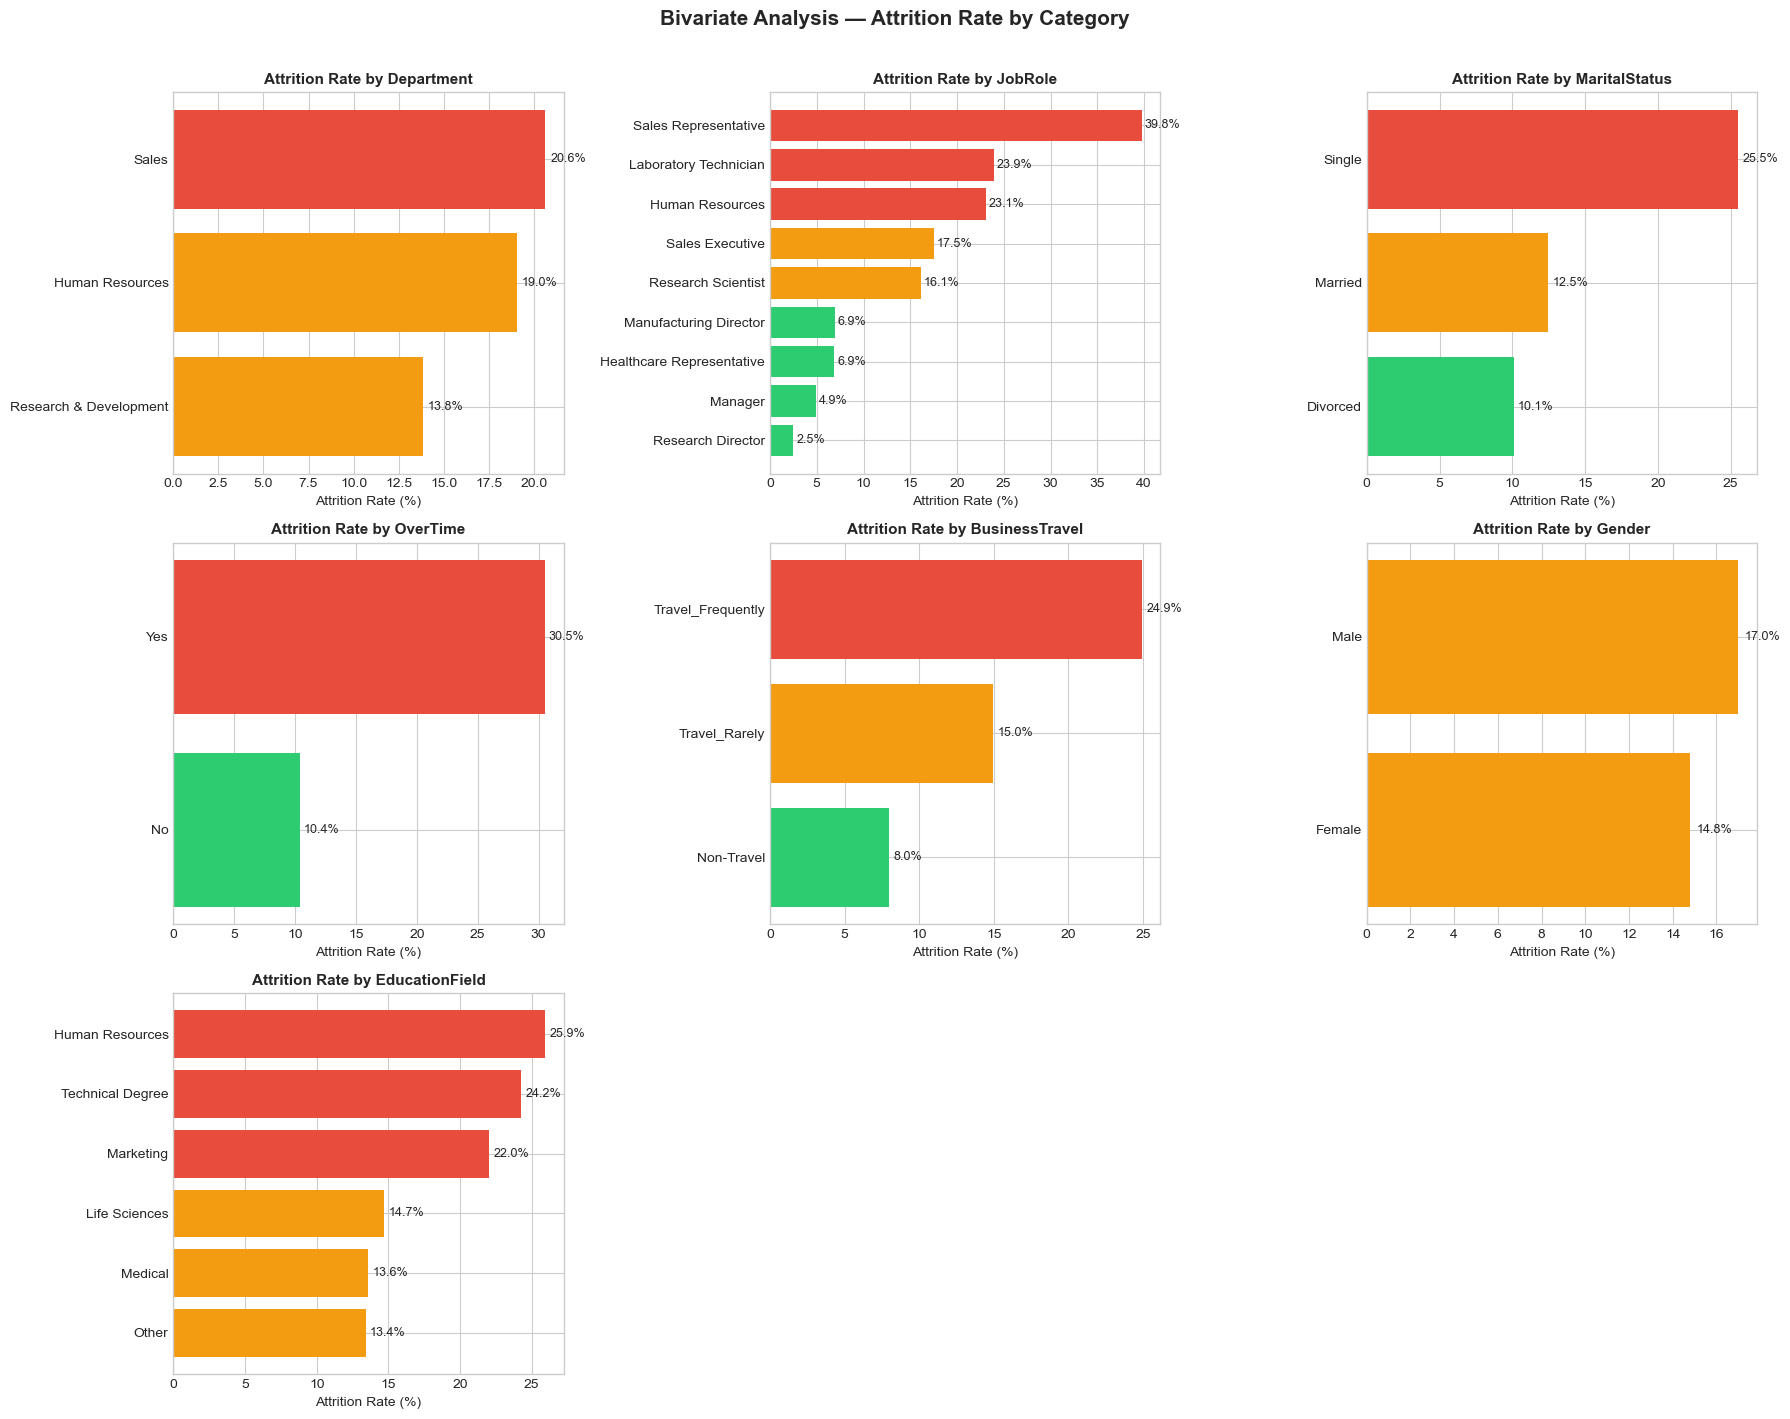


--- Department ---
Department
Sales                     20.6
Human Resources           19.0
Research & Development    13.8
Name: Attrition, dtype: float64

--- JobRole ---
JobRole
Sales Representative         39.8
Laboratory Technician        23.9
Human Resources              23.1
Sales Executive              17.5
Research Scientist           16.1
Manufacturing Director        6.9
Healthcare Representative     6.9
Manager                       4.9
Research Director             2.5
Name: Attrition, dtype: float64

--- MaritalStatus ---
MaritalStatus
Single      25.5
Married     12.5
Divorced    10.1
Name: Attrition, dtype: float64

--- OverTime ---
OverTime
Yes    30.5
No     10.4
Name: Attrition, dtype: float64

--- BusinessTravel ---
BusinessTravel
Travel_Frequently    24.9
Travel_Rarely        15.0
Non-Travel            8.0
Name: Attrition, dtype: float64

--- Gender ---
Gender
Male      17.0
Female    14.8
Name: Attrition, dtype: float64

--- EducationField ---
EducationField
Human

In [22]:
cat_features = ['Department', 'JobRole', 'MaritalStatus', 'OverTime',
                'BusinessTravel', 'Gender', 'EducationField']

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

attrition_rates = {}
for i, col in enumerate(cat_features):
    attrition_rate = df.groupby(col)['Attrition'].mean().mul(100).sort_values(ascending=True)
    attrition_rates[col] = attrition_rate
    bars = axes[i].barh(attrition_rate.index, attrition_rate.values,
                        color=['#e74c3c' if v > 20 else '#f39c12' if v > 12 else '#2ecc71'
                               for v in attrition_rate.values])
    axes[i].set_title(f'Attrition Rate by {col}', fontweight='bold', fontsize=11)
    axes[i].set_xlabel('Attrition Rate (%)')
    for bar, val in zip(bars, attrition_rate.values):
        axes[i].text(val + 0.3, bar.get_y() + bar.get_height()/2,
                     f'{val:.1f}%', va='center', fontsize=9)

for j in range(len(cat_features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Bivariate Analysis — Attrition Rate by Category', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('bivariate_categorical_attrition.png', dpi=150, bbox_inches='tight')
plt.show()

# Print exact numbers for the report/video narration
for col, rates in attrition_rates.items():
    print(f"\n--- {col} ---")
    print(rates.sort_values(ascending=False).round(1))

## Step 12 — Bivariate Analysis: Numerical vs Attrition

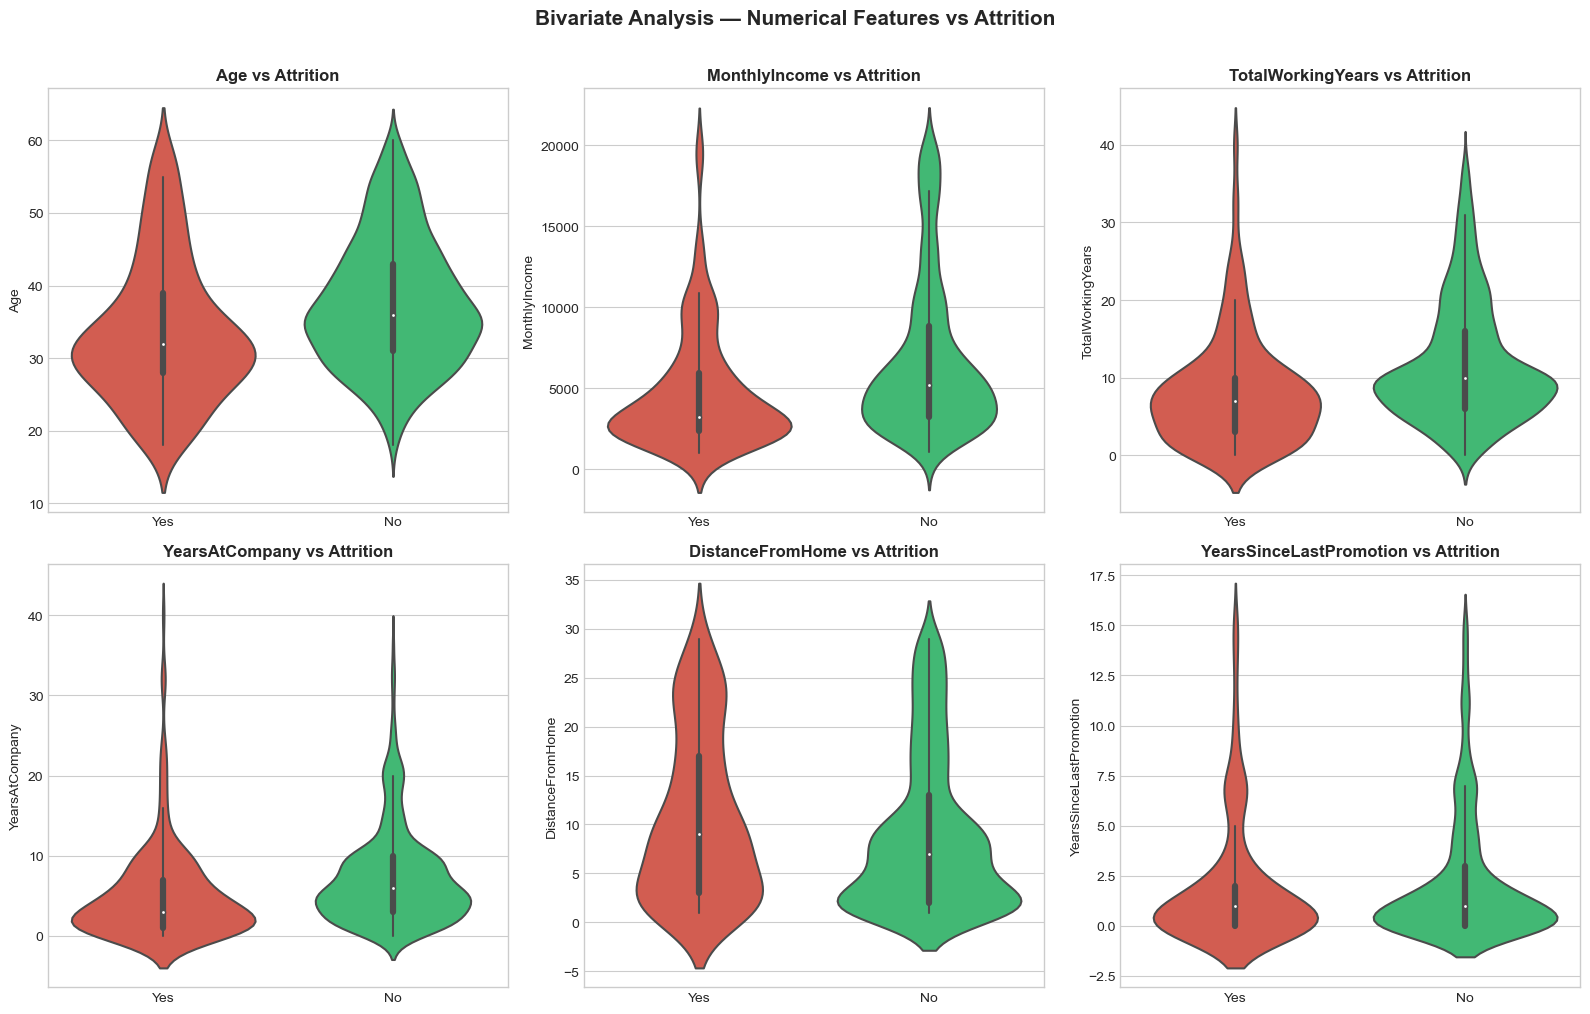

In [23]:
num_features = ['Age', 'MonthlyIncome', 'TotalWorkingYears',
                'YearsAtCompany', 'DistanceFromHome', 'YearsSinceLastPromotion']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

df_plot = df.copy()

for i, col in enumerate(num_features):
    sns.violinplot(data=df_plot, x='Attrition_Label', y=col,
                   palette={'Yes': '#e74c3c', 'No': '#2ecc71'},
                   ax=axes[i], inner='box')
    axes[i].set_title(f'{col} vs Attrition', fontweight='bold')
    axes[i].set_xlabel('')

plt.suptitle('Bivariate Analysis — Numerical Features vs Attrition', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('bivariate_numerical_attrition.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 13 — Satisfaction Scores Analysis

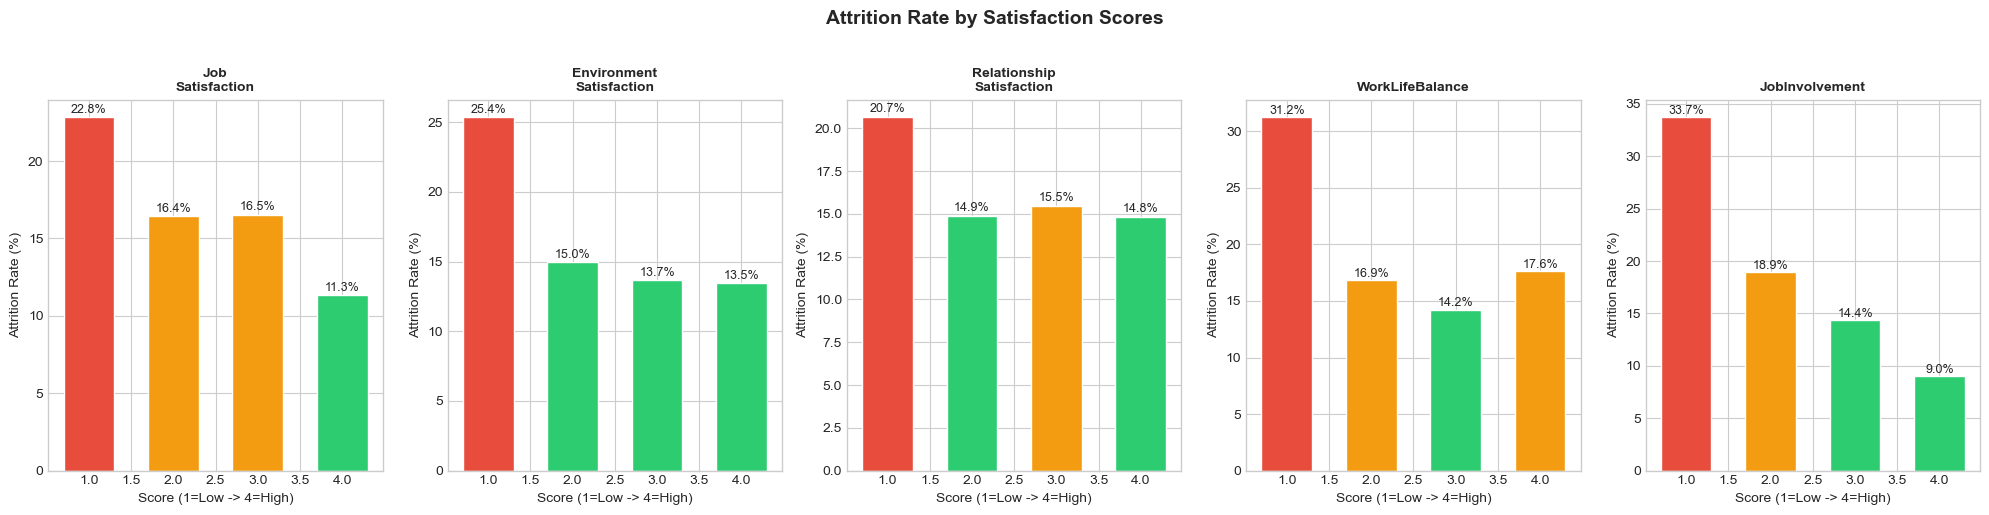

In [24]:
satisfaction_cols = ['JobSatisfaction', 'EnvironmentSatisfaction',
                     'RelationshipSatisfaction', 'WorkLifeBalance', 'JobInvolvement']

fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for i, col in enumerate(satisfaction_cols):
    attrition_by_score = df.groupby(col)['Attrition'].mean().mul(100)
    axes[i].bar(attrition_by_score.index, attrition_by_score.values,
                color=['#e74c3c' if v > 20 else '#f39c12' if v > 15 else '#2ecc71'
                       for v in attrition_by_score.values],
                edgecolor='white', width=0.6)
    axes[i].set_title(col.replace('Satisfaction','\nSatisfaction'), fontweight='bold', fontsize=10)
    axes[i].set_xlabel('Score (1=Low -> 4=High)')
    axes[i].set_ylabel('Attrition Rate (%)')
    for bar, val in zip(axes[i].patches, attrition_by_score.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                     f'{val:.1f}%', ha='center', fontsize=9)

plt.suptitle('Attrition Rate by Satisfaction Scores', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('satisfaction_vs_attrition.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 14 — Correlation Heatmap 

In [26]:
df_encoded = df.copy()
df_encoded.drop(columns=['Attrition_Label'], inplace=True)
for col in df_encoded.select_dtypes(include='object').columns:
    df_encoded[col] = pd.factorize(df_encoded[col])[0]

corr_with_target = df_encoded.corr()['Attrition'].drop('Attrition').sort_values(key=abs, ascending=False)
print("Top 15 features most correlated with Attrition:")
print(corr_with_target.head(15).round(3))

Top 15 features most correlated with Attrition:
OverTime                  -0.246
TotalWorkingYears         -0.171
JobLevel                  -0.169
MaritalStatus             -0.162
YearsInCurrentRole        -0.161
MonthlyIncome             -0.160
Age                       -0.159
YearsWithCurrManager      -0.156
StockOptionLevel          -0.137
YearsAtCompany            -0.134
JobInvolvement            -0.130
JobSatisfaction           -0.103
EnvironmentSatisfaction   -0.103
DistanceFromHome           0.078
EducationField             0.075
Name: Attrition, dtype: float64


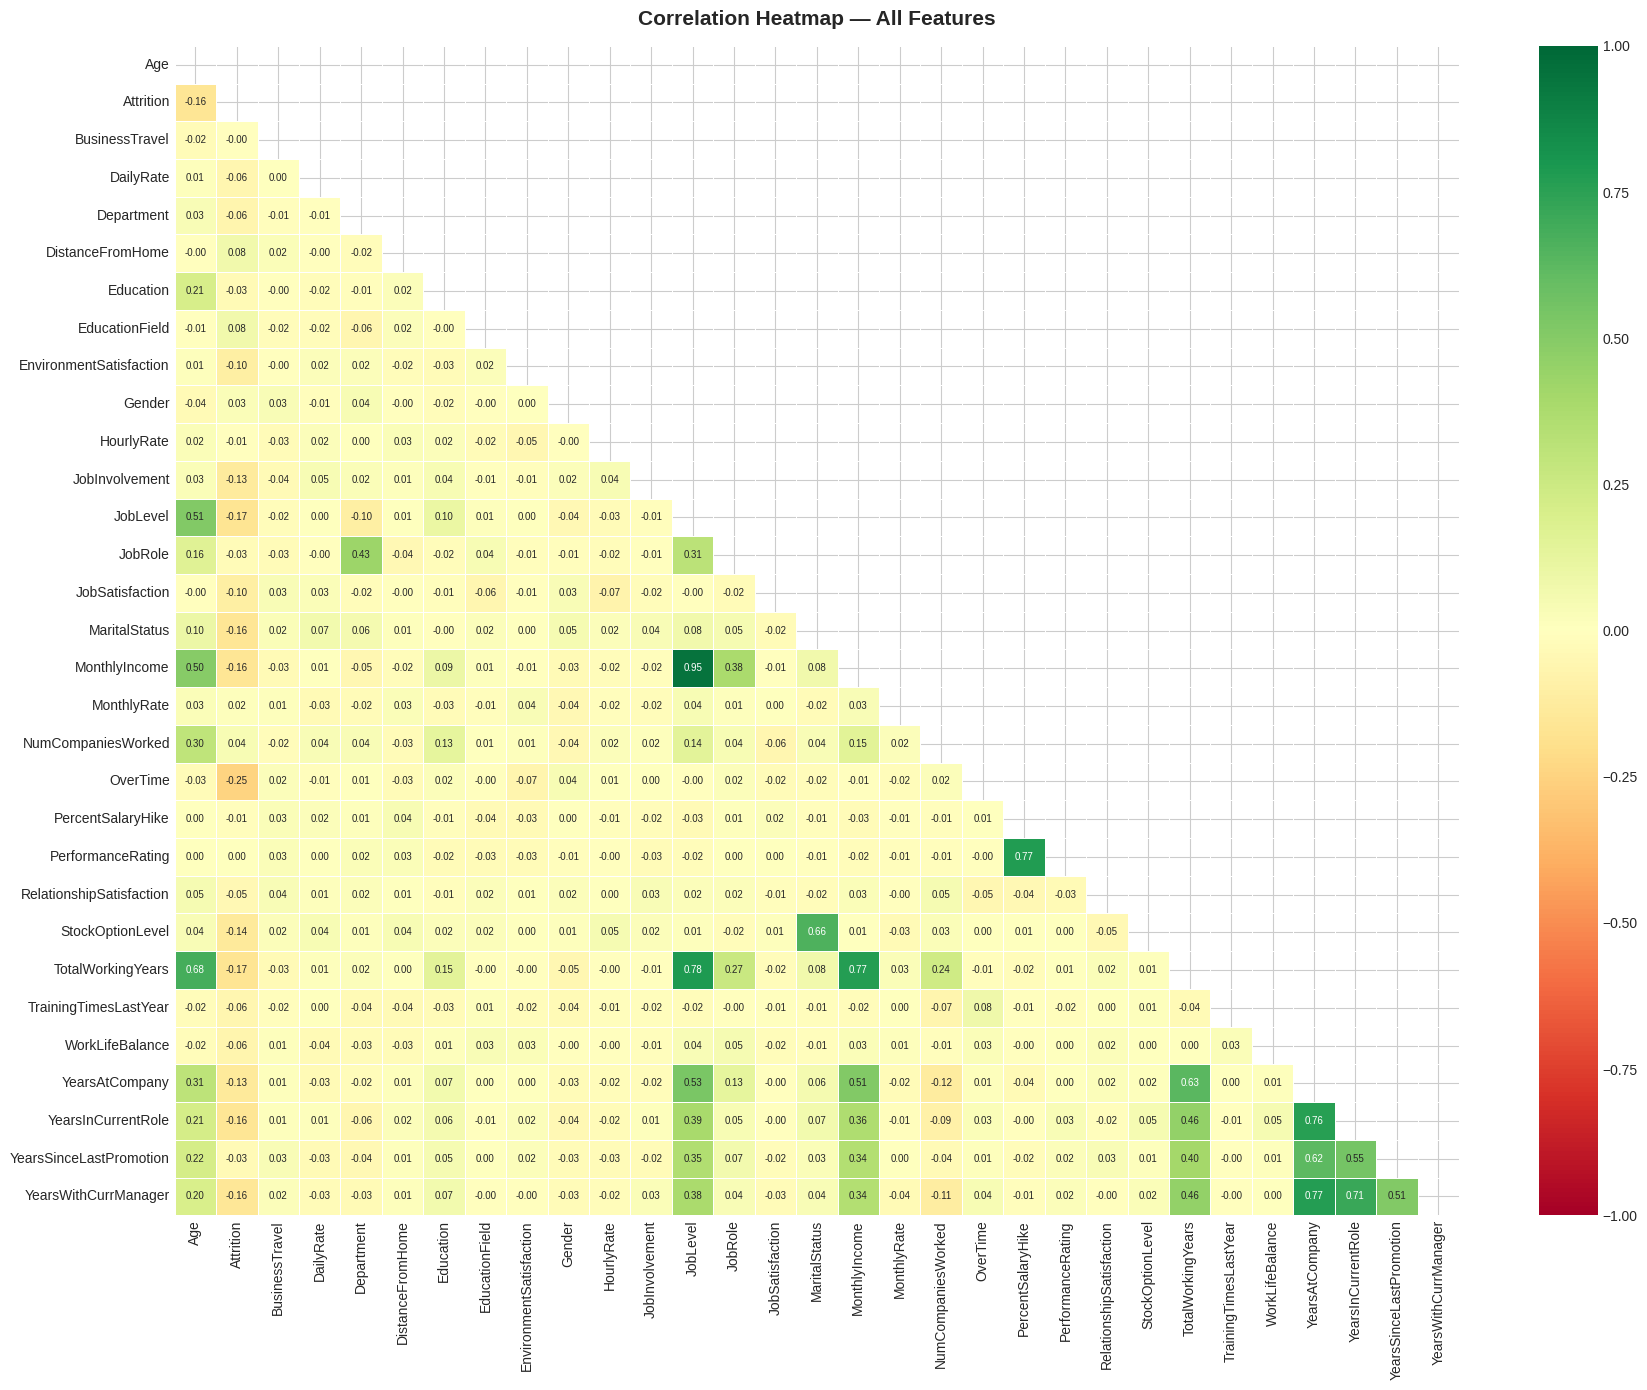

Saved: correlation_heatmap.png — use this in your Insights Tab in Week 7!


In [18]:
# Full correlation heatmap (saved for direct reuse in Week 7 Streamlit Insights Tab)
plt.figure(figsize=(18, 14))
corr_matrix = df_encoded.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, linewidths=0.5,
            annot_kws={'size': 7}, vmin=-1, vmax=1)

plt.title('Correlation Heatmap — All Features', fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: correlation_heatmap.png — use this in your Insights Tab in Week 7!')

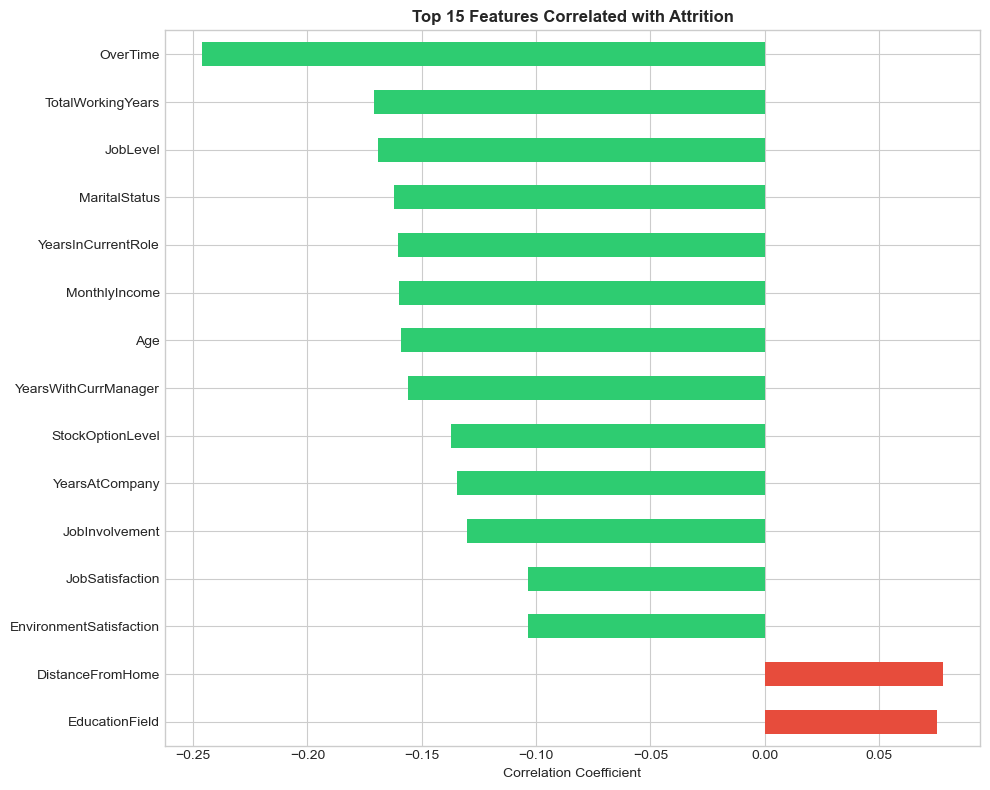

In [27]:

plt.figure(figsize=(10, 8))
top15 = corr_with_target.head(15)
colors = ['#e74c3c' if x > 0 else '#2ecc71' for x in top15]
top15.plot(kind='barh', color=colors)
plt.title('Top 15 Features Correlated with Attrition', fontweight='bold')
plt.xlabel('Correlation Coefficient')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('top_correlations_with_attrition.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 15 — Statistical Analysis (T-Test)

In [28]:
left = df[df['Attrition'] == 1]
stayed = df[df['Attrition'] == 0]

print(f"{'Column':<30} {'Left Mean':>12} {'Stayed Mean':>12} {'P-Value':>12} {'Significant?':>14}")
print('-' * 82)

ttest_results = []
for col in num_features:
    t_stat, p_val = stats.ttest_ind(left[col], stayed[col])
    sig = 'YES' if p_val < 0.05 else 'No'
    ttest_results.append((col, left[col].mean(), stayed[col].mean(), p_val, sig))
    print(f"{col:<30} {left[col].mean():>12.2f} {stayed[col].mean():>12.2f} {p_val:>12.4f} {sig:>14}")

Column                            Left Mean  Stayed Mean      P-Value   Significant?
----------------------------------------------------------------------------------
Age                                   33.61        37.56       0.0000            YES
MonthlyIncome                       4787.09      6832.74       0.0000            YES
TotalWorkingYears                      8.24        11.86       0.0000            YES
YearsAtCompany                         5.13         7.37       0.0000            YES
DistanceFromHome                      10.63         8.92       0.0028            YES
YearsSinceLastPromotion                1.95         2.23       0.2058             No


## Step 16 — Save Cleaned Dataset

In [30]:
df_final = df.drop(columns=['Attrition_Label'])
df_final.to_csv('hr_attrition_cleaned.csv', index=False)

print('Cleaned dataset saved as: hr_attrition_cleaned.csv')
print(f'Final Shape: {df_final.shape}')
print(f'Columns remaining: {list(df_final.columns)}')

Cleaned dataset saved as: hr_attrition_cleaned.csv
Final Shape: (1470, 31)
Columns remaining: ['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']
